In [27]:
import pandas as pd

#graphs 
import seaborn as sns
import matplotlib.pyplot as plt 

#stats 
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller

# Funções

In [24]:
class EdaTimeSeries():
    def __init__(self, ts: pd.DataFrame):
        self.ts = ts
    def univariate_hist_box(self):
        fig, axs = plt.subplots(2,2, figsize=(12,8))
        axs = axs.flatten()
        
        u = self.ts['y'].mean()
        md = self.ts['y'].median()
        
        sns.histplot(data=self.ts, x='y', ax=axs[0])
        axs[0].set_title('Histograma da Receita Diária')
        axs[0].axvline(x=u, color='dimgray', linestyle="--", label='media')
        axs[0].axvline(x=md, color='black', linestyle="--", label='mediana')
        axs[0].legend()
        
        sns.kdeplot(data=self.ts, x='y', ax=axs[1])
        axs[1].set_title('Densidade')
        axs[1].axvline(x=u, color='dimgray', linestyle="--", label='media')
        axs[1].axvline(x=md, color='black', linestyle="--", label='mediana')
        axs[1].legend()
        
        sns.boxplot(data=self.ts, x='y', ax=axs[2])
        axs[2].set_title('Boxplot')
        
        sns.scatterplot(data=self.ts, x=self.ts.index, y='y', ax=axs[3])
        axs[3].set_title('Dispersao')
        
        fig.tight_layout()
        plt.show()
        

# Import File

In [2]:
df = pd.read_parquet("data/silver/sales_per_region.parquet")

In [3]:
df.head(3)

,numero_do_pedido,data,status_pagamento,estado,total
0,12309,2025-06-16,Confirmado,São Paulo,101.79
1,12308,2025-06-15,Confirmado,São Paulo,187.26
2,12307,2025-06-15,Confirmado,Paraná,119.01


# EDA

## Agregação de Dados por Dia

In [11]:
ts = df.groupby("data")["total"].sum().reset_index()
ts.columns = ["ds", "y"]
ts.head(3)

,ds,y
0,2022-04-18,339.75
1,2022-04-19,99.60
2,2022-04-20,58.38


## Descritiva

In [12]:
ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1144 entries, 0 to 1143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      1144 non-null   datetime64[ns]
 1   y       1144 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 18.0 KB


In [13]:
ts.describe().T

,count,mean,min,25%,50%,75%,max,std
ds,1144,2023-11-20 05:33:33.986013952,2022-04-18 00:00:00,2023-02-05 18:00:00,2023-11-22 12:00:00,2024-09-03 06:00:00,2025-06-16 00:00:00,NaN
y,1144.0,1241.797928,20.85,638.435,1094.77,1670.0675,13543.14,907.24495


- Temos um pouco mais do que 3 anos de dados
- Média e mediana, a princípio, não muito distante uma da outra.
- O máximo valor bem acima do nosso percentil 75.

## Analise de Distribuição da Receita

In [25]:
eda = EdaTimeSeries(ts=ts)

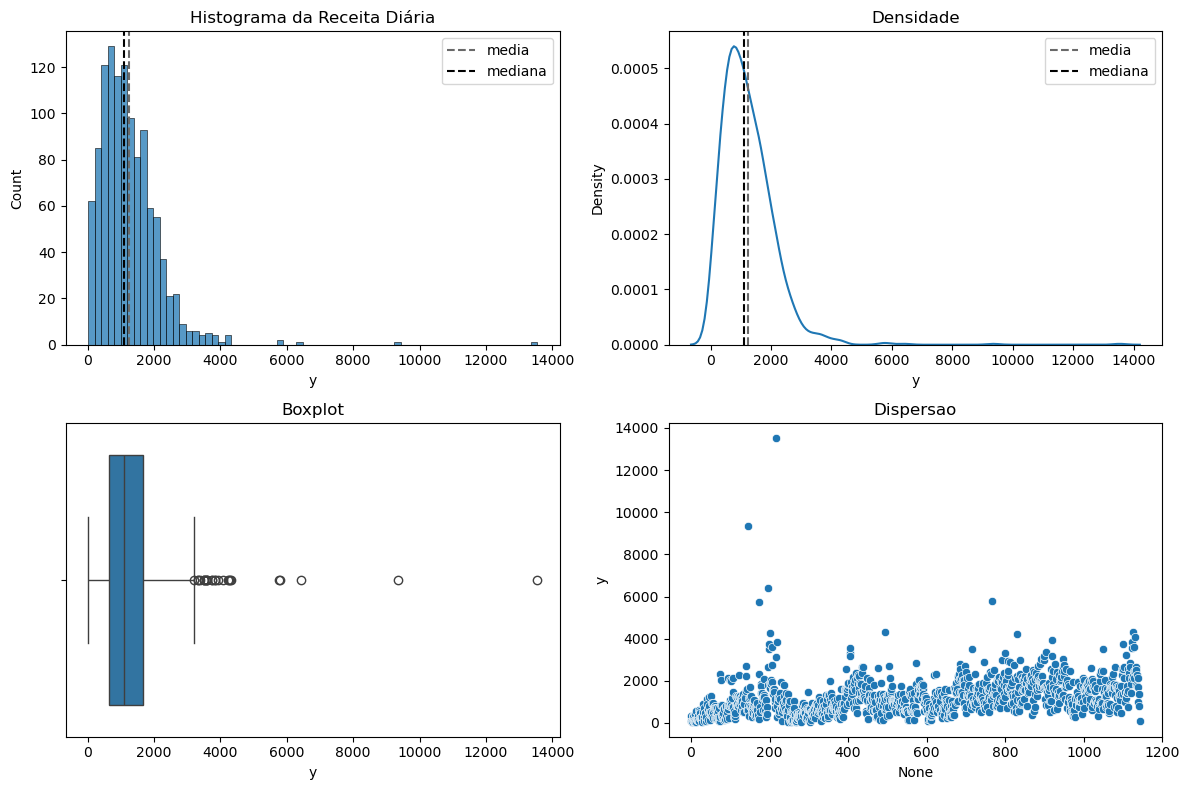

In [26]:
eda.univariate_hist_box()